In [1]:
!ls ../llm_judge/configs_chunk256_no_adj_merge

clueweb12_trec-web-2013.json  msmarco_doc_v1_test2019.json  trec-robust04.json
clueweb12_trec-web-2014.json  msmarco_doc_v1_test2020.json
gov2-mq2007.json	      msmarco_doc_v2_test2021.json


In [2]:
CONFIG_DIR='../llm_judge/configs_chunk256_no_adj_merge/'
RELEV_THRESHOLD=1

In [8]:
from math import ceil

# chunks might be one sentence off
def doclen_to_bin(pos, step=256, START_HEURISTIC_ERROR=32):
    return (START_HEURISTIC_ERROR + pos) // step

In [9]:
import json
import os
from tqdm.auto import tqdm
from flexneuart.io import FileWrapper

from collections import defaultdict

RESULTS_COPIED=True

for part_name, config_name in tqdm([
    ('web2013', 'clueweb12_trec-web-2013.json'),    
    ('web2014', 'clueweb12_trec-web-2014.json'),
    ('gov2', 'gov2-mq2007.json'), 
    ('test2019', 'msmarco_doc_v1_test2019.json'),    
    ('test2020', 'msmarco_doc_v1_test2020.json'),    
    ('test2021', 'msmarco_doc_v2_test2021.json'),
    ('robust04', 'trec-robust04.json'),    
]):
    # Initially all results are stored in the collect_root, but later
    # we moved them to another location
    if RESULTS_COPIED:
        data_root = '/disk3/collections/longp_results/relev_info'
    else:
        data_root = config['collect_root']
    
    config = json.load(open(f'{CONFIG_DIR}/{config_name}'))    
    data_file_path = f"{data_root}/{config['dataset']}/{config['output_subdir']}/{config['gpt_model_name']}/output.json"
    dt = json.load(open(data_file_path))  
    
    dir_name_raw = f'raw/{part_name}'
    os.makedirs(dir_name_raw, exist_ok=True)
    with FileWrapper(f'{dir_name_raw}/output.json.bz2', 'w') as out_f:
        json.dump(dt, out_f)    
    
    doc_lens_dict = {e['doc_id']:doclen_to_bin(e['doc_text_tok_len']) for e in dt}
    match_start_dict = {}
    for e in dt:
        start = -1 #config['chunking']['max_chunk_qty'] - 1
        for chunk_id, chunk in enumerate(e['judged_chunks']):
            if chunk['judgment'] >= RELEV_THRESHOLD:
                start = chunk_id
                break
        match_start_dict[e['doc_id']] = start
        
    dir_name = f'processed/{part_name}'
    os.makedirs(dir_name, exist_ok=True)
    with open(f'{dir_name}/doc_lens_dict.json', 'w') as out_f:
        json.dump(list(doc_lens_dict.items()), out_f)
    with open(f'{dir_name}/match_start_dict.json', 'w') as out_f:
        json.dump(list(match_start_dict.items()), out_f)       

  0%|          | 0/7 [00:00<?, ?it/s]

(array([4.720e+02, 2.436e+03, 3.830e+02, 1.690e+02, 1.040e+02, 7.600e+01,
        4.300e+01, 1.900e+01, 1.900e+01, 6.000e+00, 4.000e+00, 1.000e+00,
        1.200e+01, 3.000e+00, 2.000e+00, 0.000e+00, 6.000e+00, 5.000e+00,
        1.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00]),
 array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.,
        12., 13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24.,
        25., 26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36.]),
 <BarContainer object of 37 artists>)

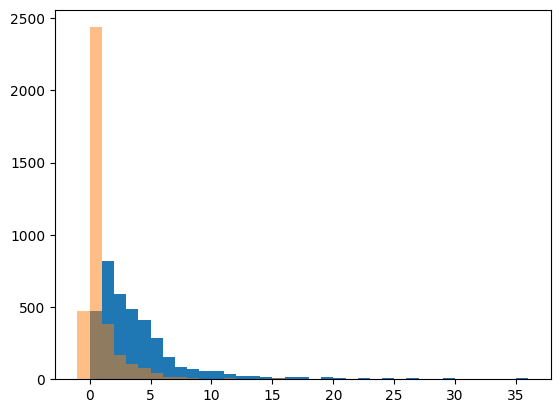

In [10]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
bins=[-1] + list(np.arange(config['chunking']['max_chunk_qty'] + 1))
plt.hist(doc_lens_dict.values(), bins=bins, alpha=1)
plt.hist(match_start_dict.values(), bins=bins, alpha=0.5)

In [ ]:
#doc_lens_dict

In [ ]:
#match_start_dict

In [ ]:
arr=np.array(list(match_start_dict.values()))

In [ ]:
len(arr), sum(arr==0)/len(arr)